<a href="https://colab.research.google.com/github/RecSys-lab/Popcorn/blob/main/examples/colab/load_ml_thumbnail_raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🍿 Popcorn Framework in Google Colab**
### **Load MovieLens-25M Thumbnails (Raw)**

🎬 Popcorn Framework: [link](https://github.com/RecSys-lab/Popcorn)

## **[Step 1] Clone Popcorn Movie Recommender Tool**

Clone the framework into your `GDrive` and prepare it for experiments.

⚠️ You might see a *"Restart Session"* warning during the first run in Google Colab due to library version mismatches. This is expected! Accept the restart, re-run this cell, and continue!

In [13]:
# Clone the repo
!git clone https://github.com/RecSys-lab/Popcorn.git

# Install the required library
%cd Popcorn
!pip install -e .

# Add the repository to the Python path
import sys
sys.path.append('/content/Popcorn')

# Go back to the root
%cd ..

fatal: destination path 'Popcorn' already exists and is not an empty directory.
/content/Popcorn
Obtaining file:///content/Popcorn
  Preparing metadata (setup.py) ... done
  Attempting uninstall: Popcorn
    Found existing installation: Popcorn 1.6.0
    Uninstalling Popcorn-1.6.0:
      Successfully uninstalled Popcorn-1.6.0
  Running setup.py develop for Popcorn


/content


## 🚀 **[Step 2] Use the Framework**

### *1. Load Configurations and Imports*

In [1]:
import os
import json
import pandas as pd
from popcorn.utils import readConfigs

# Start the Framework
print("Welcome to 'Popcorn' 🍿! Starting the framework for your movie recommendation ...\n")

# Read the configuration file
configs = readConfigs("Popcorn/popcorn/config/config.yml")
# If properly read, print the configurations
if not configs:
    print("Error reading the configuration file!")

# Get common configurations
cfgMovieLens = configs["datasets"]["unimodal"]["movielens"]
downloadPath = cfgMovieLens["download_path"]

# Override (optional)
downloadPath = "/content/MovieLens"
print(f"- Changing download path from '{cfgMovieLens['download_path']}' to: {downloadPath}")

Welcome to 'Popcorn' 🍿! Starting the framework for your movie recommendation ...

- Reading the framework's configuration file ...
- Configuration file loaded successfully!
- Changing download path from 'E:/Datasets/MovieLens' to: /content/MovieLens


### *2. Download MovieLens 25M Thumbnails*

In [6]:
from popcorn.datasets.ml_thumbnail.downloader import downloadMovieLensThumbnailImages

# Variables
partNumber = 1
downloadPath = "/content/Thumbnails"

# Download MovieLens-25M thumbnails
downloadMovieLensThumbnailImages(partNumber, downloadPath)

- Downloading part '1' MovieLens-25M thumbnails (raw images) from 'https://huggingface.co/datasets/alitourani/movielens-25m-thumb/resolve/main/thumbnails_ml25m_part1.zip' ...
- Fetching data from 'https://huggingface.co/datasets/alitourani/movielens-25m-thumb/resolve/main/thumbnails_ml25m_part1.zip' ...
- Download completed and the folder is saved as a 'zip' file!
- Extracting the dataset files inside '/content/Thumbnails/thumbnails_ml25m_part1' ...
- Dataset extracted to '/content/Thumbnails/thumbnails_ml25m_part1' successfully!
- Removing the zip file /content/Thumbnails/thumbnails_ml25m_part1.zip ...
- Zip file /content/Thumbnails/thumbnails_ml25m_part1.zip removed successfully!


True

### *3. Load MovieLens 25M Thumbnails - Indices*

In [10]:
from popcorn.datasets.ml_thumbnail.helper_raw_frame import (
    indexThumbnails,
    loadMovieThumbnail,
)

# Variables
root = "/content/Thumbnails"
configs["datasets"]["unimodal"]["ml_thumbnail"]["download_path"] = root

# Load MovieLens-25M thumbnails
thumbnailsDF = indexThumbnails(root)

display(thumbnailsDF)

- Indexing thumbnails from: /content/Thumbnails ...
- Indexed 9950 thumbnails DataFrame: 
   movieId                                               path
0     5500  /content/Thumbnails/thumbnails_ml25m_part2/550...
1    25865  /content/Thumbnails/thumbnails_ml25m_part2/258...
2     8383  /content/Thumbnails/thumbnails_ml25m_part2/838...
3     5472  /content/Thumbnails/thumbnails_ml25m_part2/547...
4    30742  /content/Thumbnails/thumbnails_ml25m_part2/307...


,movieId,path
0,5500,/content/Thumbnails/thumbnails_ml25m_part2/550...
1,25865,/content/Thumbnails/thumbnails_ml25m_part2/258...
2,8383,/content/Thumbnails/thumbnails_ml25m_part2/838...
3,5472,/content/Thumbnails/thumbnails_ml25m_part2/547...
4,30742,/content/Thumbnails/thumbnails_ml25m_part2/307...
...,...,...
9945,1495,/content/Thumbnails/thumbnails_ml25m_part1/149...
9946,1918,/content/Thumbnails/thumbnails_ml25m_part1/191...
9947,1680,/content/Thumbnails/thumbnails_ml25m_part1/168...
9948,2988,/content/Thumbnails/thumbnails_ml25m_part1/298...


### *4. Load MovieLens 25M Thumbnails - Sample Movie*

Loading thumbnail for movie ID '10'...
- Indexing thumbnails from: /content/Thumbnails ...
- Indexed 9950 thumbnails DataFrame: 
   movieId                                               path
0     5500  /content/Thumbnails/thumbnails_ml25m_part2/550...
1    25865  /content/Thumbnails/thumbnails_ml25m_part2/258...
2     8383  /content/Thumbnails/thumbnails_ml25m_part2/838...
3     5472  /content/Thumbnails/thumbnails_ml25m_part2/547...
4    30742  /content/Thumbnails/thumbnails_ml25m_part2/307...
- Loaded thumbnail for movie-id '10'!


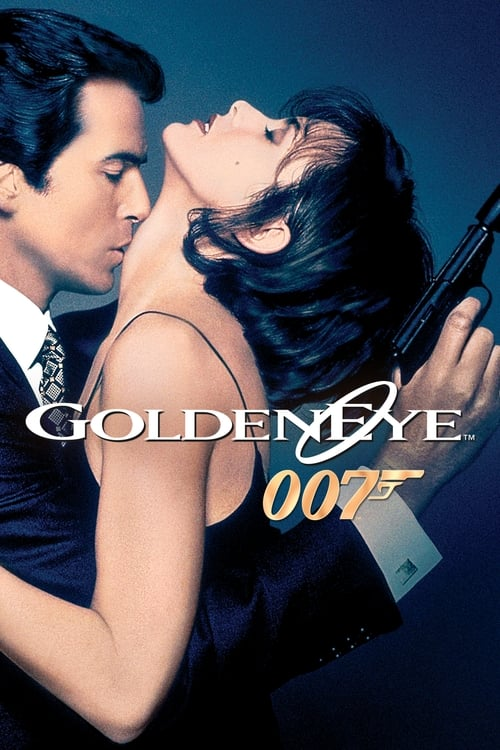

In [12]:
from google.colab.patches import cv2_imshow

# Variables
movieId = 10

# Load the Movie Thumbnail
print(f"Loading thumbnail for movie ID '{movieId}'...")
thumbnailOpenCVImage = loadMovieThumbnail(movieId, configs)

# Show the OpenCV Image
cv2_imshow(thumbnailOpenCVImage)